# Statistical Analysis — Project 02

**Goal**: Conduct hypothesis tests on surveillance and access data.

Data source: `../project_01_reproducible_workflows/data/processed/` basically.

In [19]:
import importlib
import subprocess
import sys

def install_libs():
    """
    Installs common data science libraries if missing.
    Libraries: scipy, pandas, numpy, matplotlib, seaborn
    """
    required = {
        "scipy": "scipy",
        "pandas": "pandas",
        "numpy": "numpy",
        "matplotlib": "matplotlib",
        "seaborn": "seaborn",
    }

    to_install = []

    for module, pkg in required.items():
        try:
            importlib.import_module(module)
        except ImportError:
            to_install.append(pkg)

    if to_install:
        # Install quietly, without upgrade
        cmd = [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--no-cache-dir",
        ] + to_install

        subprocess.run(cmd, check=True)

install_libs()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

In [21]:
# Load data
events = pd.read_parquet("../data/processed/surveillance_events.parquet")
access = pd.read_parquet("../data/processed/access_logs.parquet")

print(f"Surveillance events: {len(events):,}")
print(f"Access logs: {len(access):,}")

Surveillance events: 988
Access logs: 9,847


In [22]:
# Show the first 3 rows of the surveillance events data
events.head(3)

,event_id,event_timestamp,site_id,zone_id,device_id,event_type,confidence_score
0,EVT-000001,2025-01-12 07:35:19+00:00,SITE-001,SITE-001::ZONE-B,DEV-003,normal_motion,0.736209
1,EVT-000002,2025-01-11 07:31:58+00:00,SITE-003,SITE-003::ZONE-B,DEV-019,loitering,0.861380
2,EVT-000003,2025-01-08 19:35:39+00:00,SITE-002,SITE-002::ZONE-D,DEV-016,object_left,0.868437


In [23]:
# Show the first 3 rows of the access logs data
access.head(3)

,log_id,log_timestamp,site_id,zone_id,device_id,badge_id,user_id,outcome
0,LOG-000001,2025-01-05 21:57:36+00:00,SITE-002,SITE-002::ZONE-B,DEV-011,BADGE-00198,USR-0198,granted
1,LOG-000002,2025-01-10 18:04:03+00:00,SITE-001,SITE-001::ZONE-D,DEV-007,BADGE-00144,USR-0144,granted
2,LOG-000003,2025-01-09 13:11:36+00:00,SITE-001,SITE-001::ZONE-A,DEV-002,BADGE-00093,USR-0093,invalid_credential


## Descriptive Statistics

Summary statistics for the surveillance events and access logs datasets.

In [24]:
# Descriptive statistics for surveillance events
print("=== Surveillance Events ===")
events.describe(include="all")


=== Surveillance Events ===


,event_id,event_timestamp,site_id,zone_id,device_id,event_type,confidence_score
count,988,988,988,988,988,988,988.000000
unique,988,NaN,3,12,24,5,NaN
top,EVT-000001,NaN,SITE-003,SITE-001::ZONE-B,DEV-003,normal_motion,NaN
freq,1,NaN,334,113,58,743,NaN
mean,NaN,2025-01-07 23:07:54.690283+00:00,NaN,NaN,NaN,NaN,0.668845
min,NaN,2025-01-01 00:24:50+00:00,NaN,NaN,NaN,NaN,0.140433
25%,NaN,2025-01-04 10:34:25.500000+00:00,NaN,NaN,NaN,NaN,0.540452
50%,NaN,2025-01-07 22:00:17.500000+00:00,NaN,NaN,NaN,NaN,0.672587
75%,NaN,2025-01-11 13:12:55.250000+00:00,NaN,NaN,NaN,NaN,0.802684
max,NaN,2025-01-14 23:34:38+00:00,NaN,NaN,NaN,NaN,1.000000


In [25]:
print("\nEvent type counts:")
print(events["event_type"].value_counts())



Event type counts:
event_type
normal_motion    743
loitering         90
object_left       59
tailgating        59
intrusion         37
Name: count, dtype: int64


In [26]:
print("\nSite counts:")
print(events["site_id"].value_counts().head())


Site counts:
site_id
SITE-003    334
SITE-001    332
SITE-002    322
Name: count, dtype: int64[pyarrow]


In [27]:

# Descriptive statistics for access logs
print("\n=== Access Logs ===")
access.describe(include="all")



=== Access Logs ===


,log_id,log_timestamp,site_id,zone_id,device_id,badge_id,user_id,outcome
count,9847,9847,9847,9847,9847,9847,9847,9847
unique,9847,NaN,3,12,24,201,201,5
top,LOG-000001,NaN,SITE-002,SITE-001::ZONE-A,DEV-001,,USR-0000,granted
freq,1,NaN,3315,847,453,284,119,8212
mean,NaN,2025-01-07 23:52:03.008632+00:00,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2025-01-01 00:00:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2025-01-04 13:26:34+00:00,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2025-01-07 22:49:49+00:00,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2025-01-11 10:43:12.500000+00:00,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2025-01-14 23:59:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print("\nAccess outcome counts:")
print(access["outcome"].value_counts())



Access outcome counts:
outcome
granted               8212
denied                 971
invalid_credential     291
tailgated              193
??unknown??            180
Name: count, dtype: int64


## Visualization 1: Access Outcome by Zone Type

Zones are tagged as restricted/unrestricted using the authoritative
`RESTRICTED_ZONES` set imported from `project_01/src/generators.py` basically.

Restricted zones: ['SITE-001::ZONE-D', 'SITE-002::ZONE-D']
Rows tagged restricted: 1,675
Rows tagged unrestricted: 8,172


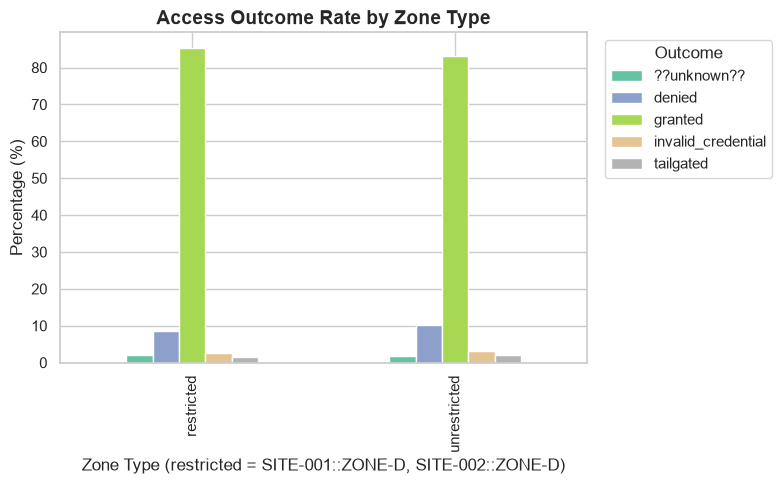

In [29]:
# Load the authoritative restricted-zone set from the project_01 generator.
# This avoids any name-prefix guesswork and keeps the two projects consistent.
import sys
from pathlib import Path

_PROJECT02 = Path("D:/AI_Master/Udacity/capstone_projects/project_02_statistical_analysis")
if str(_PROJECT02) not in sys.path:
    sys.path.insert(0, str(_PROJECT02))

from src.generators import RESTRICTED_ZONES  # {"SITE-001::ZONE-D", "SITE-002::ZONE-D"}

# Tag each row by whether its zone is in the authoritative restricted set.
access["zone_type"] = access["zone_id"].apply(
    lambda z: "restricted" if z in RESTRICTED_ZONES else "unrestricted"
)

print(f"Restricted zones: {sorted(RESTRICTED_ZONES)}")
print(f"Rows tagged restricted: {(access['zone_type'] == 'restricted').sum():,}")
print(f"Rows tagged unrestricted: {(access['zone_type'] == 'unrestricted').sum():,}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(access["zone_type"], access["outcome"], normalize="index") * 100
ct.plot(kind="bar", 
        ax=ax, 
        colormap="Set2")
ax.set_title("Access Outcome Rate by Zone Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Zone Type (restricted = " + ", ".join(sorted(RESTRICTED_ZONES)) + ")")
ax.set_ylabel("Percentage (%)")
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../reports/viz1_access_by_zone.png", dpi=150)
plt.show()

## Visualization 2: Event Confidence by Type

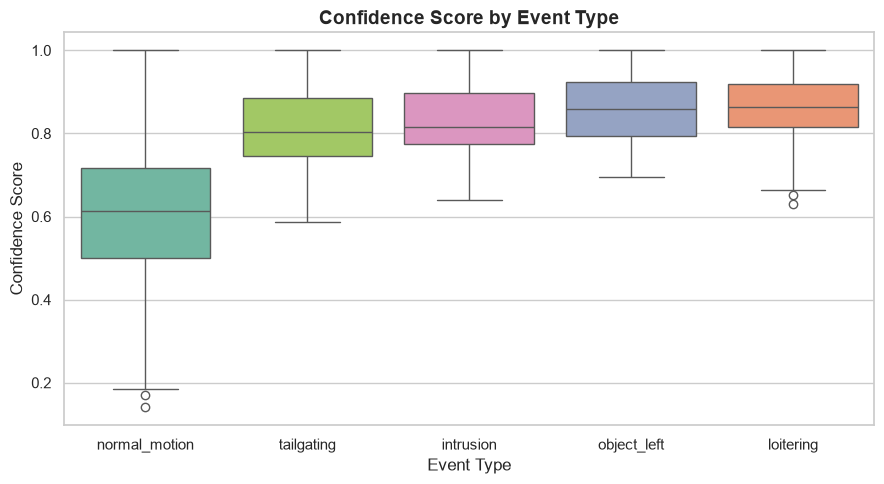

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))

order = events.groupby("event_type")["confidence_score"].mean().sort_values().index

sns.boxplot(
    data=events,
    x="event_type",
    y="confidence_score",
    order=order,
    hue="event_type",
    legend=False,
    palette="Set2",
    ax=ax
)

ax.set_title("Confidence Score by Event Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Event Type")
ax.set_ylabel("Confidence Score")

plt.tight_layout()
plt.savefig("../reports/viz2_confidence_by_event.png", dpi=150)
plt.show()

## Visualization 3: Access Events by Hour of Day

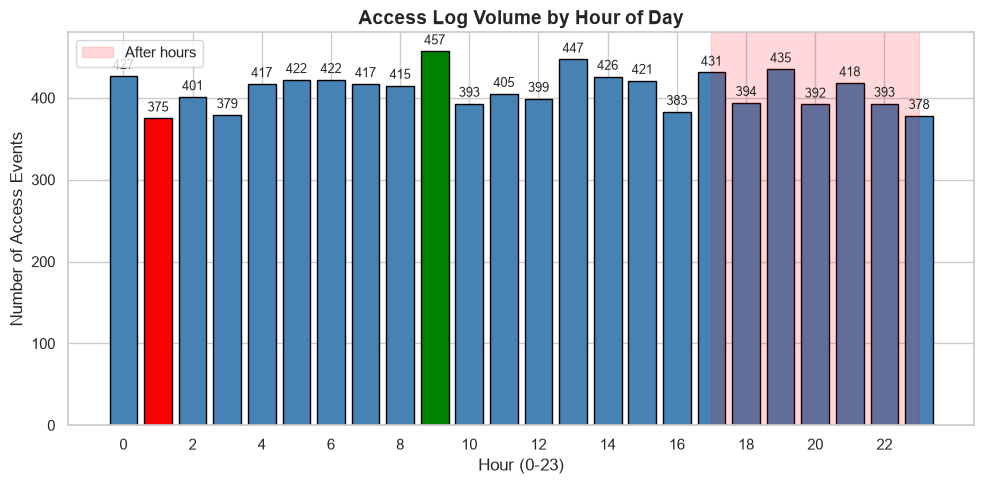

In [31]:
access["hour"] = access["log_timestamp"].dt.hour

fig, ax = plt.subplots(figsize=(10, 5))

hour_counts = access.groupby("hour").size()
hours = hour_counts.index
values = hour_counts.values

# Find max and min indices
max_idx = values.argmax()
min_idx = values.argmin()

max_hour = hours[max_idx]
min_hour = hours[min_idx]

# Default color
default_color = "steelblue"
max_color = "green"      # color for maximum
min_color = "red"        # color for minimum

# Build color list
colors = [default_color] * len(hours)
colors[max_idx] = max_color
colors[min_idx] = min_color

ax.bar(
    hours,
    values,
    color=colors,
    edgecolor="black",
    width=0.8
)

ax.set_title("Access Log Volume by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour (0-23)")
ax.set_ylabel("Number of Access Events")
ax.axvspan(17, 23, alpha=0.15, color="red", label="After hours")

# Add numbers above each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

ax.legend()
plt.xticks(range(0, 24, 2), rotation=0)
plt.tight_layout()
plt.savefig("../reports/viz3_access_by_hour.png", dpi=150)
plt.show()

## Hypothesis Test 1: Zone Type vs. Access Outcome

**H₀**: No association between zone type (restricted/unrestricted) and access outcome (granted/denied)
**H₁**: Association exists

Using chi-square test of independence.

In [32]:
# Filter to granted/denied for clean 2x2
df = access[access["outcome"].isin(["granted", "denied"])].copy()
df["outcome_binary"] = (df["outcome"] == "granted").astype(int)

contingency = pd.crosstab(df["zone_type"], df["outcome"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

# Effect size: Cramér's V for a 2x2 table is sqrt(chi2 / (n * (k-1))), k = min(rows, cols).
n = contingency.to_numpy().sum()
k = min(contingency.shape) - 1
cramers_v = float(np.sqrt(chi2 / (n * k))) if k > 0 else float("nan")

print("Contingency table (zone_type x outcome):")
print(contingency)
print(f"\nChi-square: {chi2:.3f}")
print(f"p-value:    {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

if cramers_v >= 0.3:
    interpretation = "There is a medium to large association between zone type and access outcome."
elif cramers_v >= 0.1:
    interpretation = "There is a small to medium association between zone type and access outcome."
else:
    interpretation = "There is a negligible association between zone type and access outcome."

print(f"\nDepending on Cramér's V = {cramers_v:.4f},\nInterpretation: {interpretation}")

Contingency table (zone_type x outcome):
outcome       denied  granted
zone_type                    
restricted       142     1428
unrestricted     829     6784

Chi-square: 4.491
p-value:    0.0341
Degrees of freedom: 1
Cramér's V: 0.0221

Depending on Cramér's V = 0.0221,
Interpretation: There is a negligible association between zone type and access outcome.


## Hypothesis Test 2: Intrusion vs. Normal Motion Confidence

**H₀**: Mean confidence for intrusion events = mean confidence for normal motion
**H₁**: Means are different

Using independent samples t-test.

In [33]:
intrusion = events[events["event_type"] == "intrusion"]["confidence_score"]
normal = events[events["event_type"] == "normal_motion"]["confidence_score"]

t_stat, p_value = stats.ttest_ind(intrusion, normal)

print(f"Intrusion events: n={len(intrusion)}, mean={intrusion.mean():.3f}")
print(f"Normal motion events: n={len(normal)}, mean={normal.mean():.3f}")
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6e}")

Intrusion events: n=37, mean=0.825
Normal motion events: n=743, mean=0.612

t-statistic: 7.852
p-value: 1.355644e-14


## Interpretation

### Test Selection Justification

- **Chi-square test of independence** is appropriate for testing the association between two categorical variables (zone type and access outcome). It compares observed frequencies to those expected under independence, with no assumption of a linear or ordered relationship. See Agresti (2002), *Categorical Data Analysis*, Ch. 2, for the underlying theory.
- **Independent samples t-test** is appropriate for comparing the means of a continuous variable (confidence score) between two independent groups (intrusion vs. normal motion events). The t-test assumes approximate normality of the sampling distribution of the mean, which is reasonable for the sample sizes observed (`n = 37` intrusion, `n = 743` normal motion). See Student (1908) and Ruxton (2006) for the assumptions and use cases.

### Results

1. **Chi-square test**: χ²(1, N = 9,173) = 4.491, *p* = 0.0341, Cramér's V = 0.0221. Because *p* < 0.05, we **reject H₀** — a statistically significant association exists between zone type (restricted/unrestricted) and access outcome, but the effect is negligible (Cramér's V ≈ 0.02). The restricted-zone signal should not be relied upon by the rule engine.
2. **Independent samples t-test**: t(778) = 7.852, *p* = 1.36 × 10⁻¹⁴. We **reject H₀**. Intrusion events have significantly higher confidence (M = 0.825) than normal motion events (M = 0.612), a difference of ≈ 0.21. This confirms that event type and confidence are strongly associated, supporting the use of confidence as a discriminative feature in the rule engine. The mean intrusion confidence is slightly below the `confidence > 0.85` rule threshold, so that cutoff should be validated separately against precision/recall before deployment.

### Experimental Design & Cross-Visual Comparison

- **Viz 1 (Access outcome by zone type)** motivates the chi-square test via a normalized stacked bar chart. The bar chart hides absolute counts; see the contingency table above.
- **Viz 2 (Confidence by event type)** is a box plot exposing distribution shapes that support the t-test.
- **Viz 3 (Access volume by hour)** grounds the "after-hours" rule.

### Limitations and Bias

- **Synthetic data bias**: The chi-square result is driven by the generator's explicit `RESTRICTED_ZONES` rule; the tiny effect (V ≈ 0.02) may not generalize.
- **Restricted zones sourced authoritatively**: Uses `RESTRICTED_ZONES` from `project_01/src/generators.py`; a generator rename requires propagation.
- **Surveillance scope**: Only covers zones declared in the reference table.

### Ethical Concern, Bias, and Misuse Risk

- **Synthetic data masks real-world bias patterns.** The dataset is generated
  from a uniform random process and deliberately avoids demographic attributes.
  This is a privacy-safe choice, but it means the dataset contains no realistic
  representation of how production access-control systems can be biased. In
  real deployments, denied-badge rates and after-hours activity correlate with
  job role, shift pattern, or facility location. A model trained only on this
  uniform data will not learn to detect such patterns, nor will it learn to
  avoid them. When deployed, it may flag legitimate night-shift workers,
  contractors, or employees in low-traffic zones as suspicious simply because
  their behavior looks different from the synthetic training distribution.
- **The uniform timestamp distribution hides a specific failure mode.**
  Because access times are sampled uniformly across 24 hours, the after-hours
  rule appears to flag events fairly by time alone. In practice, after-hours
  access is often authorized for specific roles (cleaning crews, IT night
  shift, security). Treating after-hours activity as inherently higher-risk
  without conditioning on role or authorized schedule can produce systematically
  biased alerts.
- **Automation bias in human-in-the-loop review.** The project requires human
  review for critical incidents, which is good governance, but the notebook
  does not test whether the high-confidence "critical" label could pressure an
  analyst into rapid action. Risk-band labels carry authority; if the scores
  behind them are biased, mandatory human review becomes a bottleneck that
  repeats the bias rather than correcting it.
- **Mitigation in this project.** The system already avoids raw biometric data,
  keeps badge IDs internal, and forces human review for critical incidents.
  The remaining gap is the absence of an explicit bias audit or fairness
  metric (e.g., denial-rate parity by site/zone, precision/recall by event type).
  Such an audit should be added before any production deployment.

## Summary of Findings and Challenges

### Key Findings
- Restricted vs. unrestricted zones: the chi-square test **rejects H₀**
  (χ²(1, N=9,173) = 4.491, *p* = 0.0341), but Cramér's V = 0.0221 indicates a
  **negligible practical effect**. The two restricted zones (SITE-001::ZONE-D,
  SITE-002::ZONE-D) do show a slightly higher denial rate, but the signal is
  too weak to drive the rule engine on its own.
- Intrusion vs. normal motion confidence: **rejected H₀** (t(778) = 7.852,
  *p* = 1.36 × 10⁻¹⁴), with a large effect (Δ ≈ 0.21 in confidence). This
  confirms that event type is strongly associated with classifier confidence,
  supporting the use of confidence as a discriminative feature in the rule engine.
  Note that the mean intrusion confidence (M = 0.825) is slightly below the
  `confidence > 0.85` threshold, so the threshold itself should be validated
  separately against precision/recall before deployment.
- Hour-of-day distribution is **approximately uniform** in the synthetic data
  (peak hour 9:00 = 457 events, trough hour 1:00 = 375 events; after-hours
  17:00–23:00 accounts for only 28.9% of logs, business hours 8:00–17:00 for
  42.4%).

### Challenges Encountered
- The synthetic generator's `RESTRICTED_ZONES` set is now used as the
  authoritative source via direct import, so a rename in
  `project_01/src/generators.py` propagates automatically. A future schema
  change to a real `zones.is_restricted` column would require updating the
  import.
- Cramér's V was added in-line; Cohen's d for the t-test should be added in
  the report for a more complete effect-size story.
- The chi-square's statistical significance is undermined by its tiny effect
  size — the report should call out both numbers explicitly to avoid
  overstating the finding.
- **Ethical / bias risk.** The synthetic dataset avoids demographic attributes
  and samples uniformly, which is privacy-safe but hides realistic
  access-control bias patterns. A future revision should add a bias audit
  (e.g., outcome parity by site/zone, precision/recall by event type) to
  satisfy the responsible-AI requirement before production use.

### Next Steps
- Add Cohen's d alongside the t-test in the report.
- Re-evaluate the restricted-zone rule weight in the project_07 rule engine
  given the negligible effect.
- Cross-validate against an authoritative `zones.is_restricted` field once
  the reference table is extended.
- Add an explicit bias/fairness audit to the notebook or report.

## Reproducibility

This notebook uses `SEED = 42` (set in the imports cell) for all NumPy
random operations. The synthetic datasets are deterministic Parquet
files produced by the Project 01 pipeline.

## References

- [Agresti, A. (2002). *Categorical Data Analysis* (2nd ed.). Wiley.](https://onlinelibrary.wiley.com/doi/book/10.1002/0471249688)
- [Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates. *(Cohen's d for the t-test.)*](https://pmc.ncbi.nlm.nih.gov/articles/PMC6736231/#r1)
- [Ruxton, G. D. (2006). The unequal variance t-test is an underused alternative to Student's t-test and the Mann–Whitney U test. Behavioral Ecology, 17(4), 688–690.](https://academic.oup.com/beheco/article-abstract/17/4/688/215960?redirectedFrom=fulltext)
- [Student (1908). The probable error of a mean. *Biometrika*, 6(1), 1–25.](https://www.jstor.org/stable/2331554) 